# MBGCN - Multi-Behavior Graph Convolutional Network
### Dataset: rees46-bpatmp-temporal (HuggingFace)
**Behaviors:** view, cart, purchase  
**Target:** Dự đoán purchase dựa trên multi-behavior

In [ ]:
# CELL 1: CÀI ĐẶT THƯ VIỆN
!pip install -q huggingface_hub

In [ ]:
# ============================================================
# CELL 2: IMPORT
# ============================================================
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import snapshot_download
import random
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
# ============================================================
# CELL 3: TẢI DATA TỪ HUGGING FACE
# ============================================================
RAW_DIR = "./rees46_raw_data"
os.makedirs(RAW_DIR, exist_ok=True)

if not any(fname.endswith('.npy') for fname in os.listdir(RAW_DIR)):
    print("Đang tải data từ HuggingFace...")
    snapshot_download(
        repo_id="nguyenmaiductrong/rees46-bpatmp-temporal",
        repo_type="dataset",
        allow_patterns="*.npy",
        local_dir=RAW_DIR
    )
    print("Tải hoàn tất!")
else:
    print(f"Data đã có trong {RAW_DIR}")

# Kiểm tra file
print("\nCác file .npy có sẵn:")
for f in sorted(os.listdir(RAW_DIR)):
    if f.endswith('.npy'):
        print(f"  {f}")

Đang tải data từ HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Tải hoàn tất!

Các file .npy có sẵn:
  candidate_item_idx.npy
  cart_train_dst.npy
  cart_train_src.npy
  cart_train_ts.npy
  purchase_train_dst.npy
  purchase_train_src.npy
  purchase_train_ts.npy
  test_product_idx.npy
  test_timestamp.npy
  test_user_idx.npy
  val_product_idx.npy
  val_timestamp.npy
  val_user_idx.npy
  view_train_dst.npy
  view_train_src.npy
  view_train_ts.npy


In [ ]:
# ============================================================
# CELL 4: LOAD VÀ KHÁM PHÁ DATA
# ============================================================
BEHAVIORS = ['view', 'cart', 'purchase']  # thứ tự quan trọng: purchase là target

def load_behavior(bhv, split='train'):
    """Load một behavior từ file .npy"""
    if split == 'train':
        u = np.load(f"{RAW_DIR}/{bhv}_train_src.npy")
        i = np.load(f"{RAW_DIR}/{bhv}_train_dst.npy")
        t = np.load(f"{RAW_DIR}/{bhv}_train_ts.npy")
    else:
        u = np.load(f"{RAW_DIR}/{split}_user_idx.npy")
        i = np.load(f"{RAW_DIR}/{split}_product_idx.npy")
        t = np.load(f"{RAW_DIR}/{split}_timestamp.npy")
    return u, i, t

# Load tất cả behaviors
behavior_data = {}
for bhv in BEHAVIORS:
    u, i, t = load_behavior(bhv, 'train')
    behavior_data[bhv] = {'user': u, 'item': i, 'ts': t}
    print(f"[{bhv}] {len(u):,} interactions | users: {u.max()+1:,} | items: {i.max()+1:,}")

# Lấy số lượng user/item
NUM_USERS = max(behavior_data[b]['user'].max() for b in BEHAVIORS) + 1
NUM_ITEMS = max(behavior_data[b]['item'].max() for b in BEHAVIORS) + 1
print(f"\nTổng: {NUM_USERS:,} users | {NUM_ITEMS:,} items")

[view] 25,956,733 interactions | users: 203,062 | items: 29,892
[cart] 3,868,050 interactions | users: 203,062 | items: 29,892
[purchase] 2,436,760 interactions | users: 203,063 | items: 29,892

Tổng: 203,063 users | 29,892 items


In [ ]:
# ============================================================
# CELL 5: XÂY DỰNG MA TRẬN TƯƠNG TÁC & LAPLACIAN
# ============================================================
def build_interaction_matrix(users, items, num_users, num_items):
    """Tạo sparse matrix user-item"""
    data = np.ones(len(users))
    mat = sp.csr_matrix((data, (users, items)), shape=(num_users, num_items))
    mat.data[:] = 1.0  # binarize
    return mat

def build_normalized_laplacian(mat):
    """
    Tạo normalized Laplacian cho đồ thị user-item bipartite:
    L = D^(-1/2) * A * D^(-1/2)
    A = [[0, R], [R^T, 0]]
    """
    n_users, n_items = mat.shape

    # Tạo adjacency matrix đối xứng
    upper = sp.hstack([sp.csr_matrix((n_users, n_users)), mat])
    lower = sp.hstack([mat.T, sp.csr_matrix((n_items, n_items))])
    adj = sp.vstack([upper, lower]).tocsr()

    # Degree normalization
    degrees = np.array(adj.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1e-10
    d_inv_sqrt = np.power(degrees, -0.5)
    D_inv_sqrt = sp.diags(d_inv_sqrt)

    laplacian = D_inv_sqrt @ adj @ D_inv_sqrt
    return laplacian

def sparse_to_tensor(sparse_mat):
    """Chuyển scipy sparse sang torch sparse tensor"""
    coo = sparse_mat.tocoo()
    indices = torch.LongTensor(np.array([coo.row, coo.col]))
    values = torch.FloatTensor(coo.data)
    shape = torch.Size(coo.shape)
    return torch.sparse_coo_tensor(indices, values, shape).to(device)

# Xây dựng cho từng behavior
print("Đang xây dựng Laplacian matrices...")
behavior_matrices = {}  # sparse tensors
interaction_mats = {}   # scipy sparse

for bhv in BEHAVIORS:
    d = behavior_data[bhv]
    mat = build_interaction_matrix(d['user'], d['item'], NUM_USERS, NUM_ITEMS)
    laplacian = build_normalized_laplacian(mat)
    interaction_mats[bhv] = mat
    behavior_matrices[bhv] = sparse_to_tensor(laplacian)
    print(f"  [{bhv}] Laplacian shape: {laplacian.shape}, nnz: {laplacian.nnz:,}")

print("\nHoàn tất xây dựng đồ thị!")

Đang xây dựng Laplacian matrices...
  [view] Laplacian shape: (232955, 232955), nnz: 20,620,320
  [cart] Laplacian shape: (232955, 232955), nnz: 3,156,376
  [purchase] Laplacian shape: (232955, 232955), nnz: 2,617,460

Hoàn tất xây dựng đồ thị!


In [ ]:
# ============================================================
# CELL 6: MBGCN MODEL
# ============================================================
class BehaviorGraphConv(nn.Module):
    """
    Graph Convolution cho một behavior cụ thể.
    Thực hiện message passing: E' = L * E
    """
    def __init__(self):
        super().__init__()

    def forward(self, embeddings, laplacian):
        """embeddings: (n_users + n_items, embed_dim)"""
        return torch.sparse.mm(laplacian, embeddings)


class MBGCN(nn.Module):
    """
    Multi-Behavior Graph Convolutional Network

    Ý tưởng chính:
    - Mỗi behavior có đồ thị riêng
    - Lan truyền thông tin qua L lớp GCN cho từng behavior
    - Kết hợp embedding từ tất cả behaviors với attention weights
    - Loss: BPR trên behavior target (purchase)
    """
    def __init__(
        self,
        num_users,
        num_items,
        behaviors,
        embed_dim=64,
        n_layers=3,
        reg_weight=1e-5,
    ):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.behaviors = behaviors
        self.n_behaviors = len(behaviors)
        self.embed_dim = embed_dim
        self.n_layers = n_layers
        self.reg_weight = reg_weight

        # ── Embedding layers ──────────────────────────────────────────
        # Mỗi behavior có embedding riêng cho user và item
        self.user_embeds = nn.ModuleList([
            nn.Embedding(num_users, embed_dim) for _ in behaviors
        ])
        self.item_embeds = nn.ModuleList([
            nn.Embedding(num_items, embed_dim) for _ in behaviors
        ])

        # ── Graph Convolution ─────────────────────────────────────────
        self.gcn = BehaviorGraphConv()

        # ── Behavior Aggregation (Attention) ──────────────────────────
        # Học tầm quan trọng của từng behavior
        self.behavior_attn = nn.Parameter(torch.ones(self.n_behaviors))

        # ── Cross-behavior Interaction ────────────────────────────────
        # Chiếu embedding tổng hợp về embed_dim
        self.user_transform = nn.Linear(embed_dim * self.n_behaviors, embed_dim)
        self.item_transform = nn.Linear(embed_dim * self.n_behaviors, embed_dim)

        # ── Init weights ──────────────────────────────────────────────
        self._init_weights()

    def _init_weights(self):
        for embed in self.user_embeds:
            nn.init.xavier_uniform_(embed.weight)
        for embed in self.item_embeds:
            nn.init.xavier_uniform_(embed.weight)
        nn.init.xavier_uniform_(self.user_transform.weight)
        nn.init.xavier_uniform_(self.item_transform.weight)

    def get_behavior_embeddings(self, b_idx, laplacian):
        """
        Lấy embedding sau n_layers GCN cho behavior b_idx.
        Trả về (user_embed, item_embed) sau khi aggregate qua các lớp.
        """
        # Concat user và item embeddings
        all_emb = torch.cat([
            self.user_embeds[b_idx].weight,
            self.item_embeds[b_idx].weight
        ], dim=0)  # (n_users + n_items, embed_dim)

        # Lưu embedding từng layer
        layer_embs = [all_emb]
        for _ in range(self.n_layers):
            all_emb = self.gcn(all_emb, laplacian)
            layer_embs.append(all_emb)

        # Mean pooling qua các lớp (như LightGCN)
        final_emb = torch.stack(layer_embs, dim=0).mean(dim=0)

        user_emb = final_emb[:self.num_users]
        item_emb = final_emb[self.num_users:]
        return user_emb, item_emb

    def forward(self, behavior_laplacians):
        """
        behavior_laplacians: dict {behavior_name: sparse_tensor}
        Trả về embedding tổng hợp của users và items.
        """
        all_user_embs = []
        all_item_embs = []

        attn_weights = F.softmax(self.behavior_attn, dim=0)  # (n_behaviors,)

        for b_idx, bhv in enumerate(self.behaviors):
            u_emb, i_emb = self.get_behavior_embeddings(b_idx, behavior_laplacians[bhv])
            all_user_embs.append(u_emb * attn_weights[b_idx])
            all_item_embs.append(i_emb * attn_weights[b_idx])

        # Concat và transform
        user_concat = torch.cat(all_user_embs, dim=1)  # (n_users, embed_dim * n_behaviors)
        item_concat = torch.cat(all_item_embs, dim=1)  # (n_items, embed_dim * n_behaviors)

        user_final = self.user_transform(user_concat)   # (n_users, embed_dim)
        item_final = self.item_transform(item_concat)   # (n_items, embed_dim)

        return user_final, item_final

    def bpr_loss(self, users, pos_items, neg_items, behavior_laplacians):
        """Bayesian Personalized Ranking Loss"""
        user_emb, item_emb = self.forward(behavior_laplacians)

        u = user_emb[users]        # (batch, embed_dim)
        pos = item_emb[pos_items]  # (batch, embed_dim)
        neg = item_emb[neg_items]  # (batch, embed_dim)

        pos_scores = (u * pos).sum(dim=1)
        neg_scores = (u * neg).sum(dim=1)

        bpr = -F.logsigmoid(pos_scores - neg_scores).mean()

        # L2 regularization trên embedding gốc (chỉ behavior purchase)
        target_b = self.behaviors.index('purchase')
        reg_loss = (
            self.user_embeds[target_b].weight[users].norm(2).pow(2) +
            self.item_embeds[target_b].weight[pos_items].norm(2).pow(2) +
            self.item_embeds[target_b].weight[neg_items].norm(2).pow(2)
        ) / len(users)

        return bpr + self.reg_weight * reg_loss


print("Model MBGCN đã định nghĩa xong!")

Model MBGCN đã định nghĩa xong!


In [ ]:
# ============================================================
# CELL 7: DATASET CHO TRAINING (BPR Sampling)
# ============================================================
class MBGCNDataset(Dataset):
    """
    Dataset với negative sampling.
    Train trên behavior target = purchase.
    """
    def __init__(self, interaction_mat, num_users, num_items, num_neg=1):
        """
        interaction_mat: scipy sparse matrix (user x item) của purchase
        """
        self.num_users = num_users
        self.num_items = num_items
        self.num_neg = num_neg

        # Lấy tất cả positive pairs (user, item)
        coo = interaction_mat.tocoo()
        self.users = coo.row
        self.items = coo.col

        # Tạo set positive items cho mỗi user (để negative sampling)
        self.user_pos_items = {}
        for u, i in zip(self.users, self.items):
            if u not in self.user_pos_items:
                self.user_pos_items[u] = set()
            self.user_pos_items[u].add(i)

        print(f"Dataset: {len(self.users):,} positive pairs")

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        user = self.users[idx]
        pos_item = self.items[idx]

        # Negative sampling
        neg_item = random.randint(0, self.num_items - 1)
        while neg_item in self.user_pos_items.get(user, set()):
            neg_item = random.randint(0, self.num_items - 1)

        return (
            torch.LongTensor([user]),
            torch.LongTensor([pos_item]),
            torch.LongTensor([neg_item])
        )


# Tạo dataset từ purchase interactions
train_dataset = MBGCNDataset(
    interaction_mat=interaction_mats['purchase'],
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4096,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

Dataset: 1,308,730 positive pairs


In [ ]:
# ============================================================
# CELL 8: LOAD VALIDATION & TEST DATA
# ============================================================
def load_eval_data(split):
    """Load val hoặc test data"""
    u = np.load(f"{RAW_DIR}/{split}_user_idx.npy")
    i = np.load(f"{RAW_DIR}/{split}_product_idx.npy")
    # Group by user
    user_items = {}
    for user, item in zip(u, i):
        if user not in user_items:
            user_items[user] = []
        user_items[user].append(item)
    return user_items

val_data = load_eval_data('val')
test_data = load_eval_data('test')
print(f"Val: {len(val_data):,} users")
print(f"Test: {len(test_data):,} users")

Val: 47,996 users
Test: 23,536 users


In [ ]:
# ============================================================
# CELL 9: HÀM ĐÁNH GIÁ (HR@K, NDCG@K) — dùng TemporalSplitEvaluator
# ============================================================
from dataclasses import dataclass, field
from typing import Any
import gc

EMBED_DIM = 64  # phải khớp với config model

# ── EvalInput contract (inline, không cần file riêng) ────────────────────────
@dataclass
class EvalInput:
    user_embeddings: torch.Tensor          # (n_eval_users, dim)
    item_embeddings: torch.Tensor          # (n_items, dim)
    eval_user_ids:   torch.Tensor          # (n_eval_users,)  — global user ids
    ground_truth:    dict[int, Any]        # uid -> item_id | list[item_id]
    exclude_items:   dict[int, list[int]]  # uid -> [train item ids to mask]

    @staticmethod
    def _as_item_list(x) -> list[int]:
        if isinstance(x, (list, tuple)):
            return [int(i) for i in x]
        return [int(x)]

    def validate(self):
        assert self.user_embeddings.size(0) == self.eval_user_ids.size(0)
        assert self.user_embeddings.size(1) == self.item_embeddings.size(1)


# ── TemporalSplitEvaluator ───────────────────────────────────────────────────
class TemporalSplitEvaluator:
    """Full-rank evaluator. Metrics: HR@k, NDCG@k (multi-positive)."""

    def __init__(self, ks=None, device="cpu"):
        self.ks = sorted(ks or [1, 5, 10, 20, 50])
        self.max_k = max(self.ks)
        if device == "cuda" and not torch.cuda.is_available():
            device = "cpu"
        self.device = torch.device(device)

    @torch.no_grad()
    def evaluate_full_ranking_tiled(
        self,
        eval_input: EvalInput,
        user_batch: int = 512,
        item_tile: int = 16384,
    ) -> dict[str, float]:
        eval_input.validate()
        n_eval  = eval_input.eval_user_ids.size(0)
        n_items = eval_input.item_embeddings.size(0)
        dev     = self.device

        dtype    = torch.float16 if dev.type == "cuda" else torch.float32
        item_embs = eval_input.item_embeddings.to(device=dev, dtype=dtype)

        # exclude mask (flatten)
        uid_to_pos = {int(u): i for i, u in enumerate(eval_input.eval_user_ids.tolist())}
        excl_rows, excl_cols = [], []
        for uid, items in eval_input.exclude_items.items():
            pos = uid_to_pos.get(int(uid))
            if pos is None or not items:
                continue
            excl_rows.extend([pos] * len(items))
            excl_cols.extend(int(x) for x in items)
        excl_rows_t = torch.as_tensor(excl_rows, dtype=torch.long, device=dev)
        excl_cols_t = torch.as_tensor(excl_cols, dtype=torch.long, device=dev)

        # ground truth padded tensor
        gt_lists  = [EvalInput._as_item_list(eval_input.ground_truth[int(u)])
                     for u in eval_input.eval_user_ids.tolist()]
        max_pos   = max(len(x) for x in gt_lists)
        gt_padded = torch.full((n_eval, max_pos), -1, dtype=torch.long, device=dev)
        gt_counts = torch.empty(n_eval, dtype=torch.long, device=dev)
        for row, items in enumerate(gt_lists):
            gt_counts[row] = len(items)
            gt_padded[row, :len(items)] = torch.tensor(items, dtype=torch.long, device=dev)

        ndcg_w = 1.0 / torch.log2(torch.arange(1, self.max_k + 1, device=dev).float() + 1.0)
        sums = {f"{m}@{k}": 0.0 for m in ("HR", "NDCG") for k in self.ks}

        for u_start in range(0, n_eval, user_batch):
            u_end = min(u_start + user_batch, n_eval)
            B     = u_end - u_start
            u_emb = eval_input.user_embeddings[u_start:u_end].to(device=dev, dtype=dtype)

            top_vals = torch.full((B, self.max_k), float("-inf"), device=dev, dtype=dtype)
            top_idx  = torch.full((B, self.max_k), -1, device=dev, dtype=torch.long)

            in_batch  = (excl_rows_t >= u_start) & (excl_rows_t < u_end)
            sub_rows  = excl_rows_t[in_batch] - u_start
            sub_cols  = excl_cols_t[in_batch]

            for i_start in range(0, n_items, item_tile):
                i_end  = min(i_start + item_tile, n_items)
                tile   = item_embs[i_start:i_end]
                scores = u_emb @ tile.T

                tile_mask = (sub_cols >= i_start) & (sub_cols < i_end)
                if tile_mask.any():
                    scores[sub_rows[tile_mask], sub_cols[tile_mask] - i_start] = float("-inf")

                kk = min(self.max_k, scores.size(1))
                tv, ti = scores.topk(kk, dim=-1)
                ti = ti + i_start

                merged_v = torch.cat([top_vals, tv], dim=-1)
                merged_i = torch.cat([top_idx,  ti], dim=-1)
                sel      = merged_v.topk(self.max_k, dim=-1).indices
                top_vals = merged_v.gather(1, sel)
                top_idx  = merged_i.gather(1, sel)

            batch_gt     = gt_padded[u_start:u_end]
            batch_counts = gt_counts[u_start:u_end]
            hits = (top_idx.unsqueeze(-1) == batch_gt.unsqueeze(1)).any(dim=-1)

            for k in self.ks:
                sums[f"HR@{k}"]   += hits[:, :k].any(dim=-1).float().sum().item()
                dcg  = (hits[:, :k].float() * ndcg_w[:k]).sum(dim=-1)
                ideal_len = torch.minimum(batch_counts, torch.full_like(batch_counts, k))
                idcg = torch.zeros_like(dcg)
                for ik in ideal_len.unique():
                    mask = ideal_len == ik
                    if int(ik.item()) > 0:
                        idcg[mask] = ndcg_w[:int(ik.item())].sum()
                sums[f"NDCG@{k}"] += (dcg / idcg.clamp_min(1e-12)).sum().item()

            del u_emb, top_vals, top_idx, hits

        del item_embs
        gc.collect()
        if dev.type == "cuda":
            torch.cuda.empty_cache()

        return {k: v / n_eval for k, v in sums.items()}

    def evaluate(self, eval_input, batch_size=512):
        return self.evaluate_full_ranking_tiled(eval_input, user_batch=batch_size)


# ── Hàm wrapper gọi trong training loop ─────────────────────────────────────
@torch.no_grad()
def evaluate(model, behavior_laplacians, eval_data, train_mat, topk=[1, 5, 10, 20, 50]):
    """
    Wrapper: lấy embedding từ MBGCN → đóng gói EvalInput → gọi TemporalSplitEvaluator.
    Trả về dict: HR@1, HR@5, ..., NDCG@1, NDCG@5, ...
    """
    model.eval()
    user_emb_all, item_emb_all = model(behavior_laplacians)
    # Chuyển về CPU float32 để tiết kiệm VRAM
    user_emb_all = user_emb_all.detach().cpu().float()
    item_emb_all = item_emb_all.detach().cpu().float()

    eval_users  = list(eval_data.keys())
    eval_uids_t = torch.tensor(eval_users, dtype=torch.long)

    # exclude: mask purchase train items cho mỗi eval user
    train_csr = train_mat.tocsr()
    exclude = {}
    for u in eval_users:
        train_items = train_csr[u].indices.tolist()
        if train_items:
            exclude[u] = train_items

    eval_input = EvalInput(
        user_embeddings = user_emb_all[eval_uids_t],   # chỉ lấy eval users
        item_embeddings = item_emb_all,
        eval_user_ids   = torch.arange(len(eval_users)),  # local idx
        ground_truth    = {i: items for i, (u, items) in enumerate(eval_data.items())},
        exclude_items   = {i: exclude.get(u, []) for i, u in enumerate(eval_users)},
    )

    evaluator = TemporalSplitEvaluator(
        ks=topk,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    return evaluator.evaluate(eval_input)


print("TemporalSplitEvaluator sẵn sàng! Metrics: HR@K, NDCG@K")


TemporalSplitEvaluator sẵn sàng! Metrics: HR@K, NDCG@K


In [ ]:
# ============================================================
# CELL 10: KHỞI TẠO MODEL & OPTIMIZER
# ============================================================
# ── Config ────────────────────────────────────────────────────
EMBED_DIM = 64
N_LAYERS = 3
REG_WEIGHT = 1e-5
LEARNING_RATE = 0.001
EPOCHS = 40
EARLY_STOP_PATIENCE = 5
TOPK = [1, 5, 10, 20, 50]
CHECKPOINT_DIR = "./checkpoints_mbgcn"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Khởi tạo model ────────────────────────────────────────────
model = MBGCN(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    behaviors=BEHAVIORS,
    embed_dim=EMBED_DIM,
    n_layers=N_LAYERS,
    reg_weight=REG_WEIGHT,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# In thông tin model
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: MBGCN")
print(f"Users: {NUM_USERS:,} | Items: {NUM_ITEMS:,}")
print(f"Behaviors: {BEHAVIORS}")
print(f"Embed dim: {EMBED_DIM} | Layers: {N_LAYERS}")
print(f"Total params: {total_params:,}")
print(f"\nBehavior attention weights (init): {F.softmax(model.behavior_attn, dim=0).detach().cpu().numpy()}")

Model: MBGCN
Users: 203,063 | Items: 29,892
Behaviors: ['view', 'cart', 'purchase']
Embed dim: 64 | Layers: 3
Total params: 44,752,067

Behavior attention weights (init): [0.33333334 0.33333334 0.33333334]


In [ ]:
# ============================================================
# CELL 11: TRAINING LOOP
# ============================================================
best_ndcg = 0.0
best_epoch = 0
patience_counter = 0
history = []

print("=" * 60)
print("BẮT ĐẦU HUẤN LUYỆN MBGCN")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    t0 = time.time()

    for batch_users, batch_pos, batch_neg in train_loader:
        batch_users = batch_users.squeeze().to(device)
        batch_pos = batch_pos.squeeze().to(device)
        batch_neg = batch_neg.squeeze().to(device)

        optimizer.zero_grad()
        loss = model.bpr_loss(batch_users, batch_pos, batch_neg, behavior_matrices)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    elapsed = time.time() - t0

    # ── Validation ────────────────────────────────────────────
    val_results = evaluate(
        model, behavior_matrices, val_data, interaction_mats['purchase'],
        topk=TOPK
    )

    ndcg20 = val_results['NDCG@20']
    hr20    = val_results['HR@20']

    # Log behavior attention
    attn = F.softmax(model.behavior_attn, dim=0).detach().cpu().numpy()
    attn_str = ', '.join([f"{b}={a:.3f}" for b, a in zip(BEHAVIORS, attn)])

    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
          f"HR@20: {hr20:.4f} | NDCG@20: {ndcg20:.4f} | "
          f"Attn: [{attn_str}] | {elapsed:.1f}s")

    history.append({'epoch': epoch, 'loss': avg_loss, **val_results})

    # ── Early Stopping & Checkpoint ───────────────────────────
    if ndcg20 > best_ndcg:
        best_ndcg = ndcg20
        best_epoch = epoch
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_results': val_results,

        }, f"{CHECKPOINT_DIR}/mbgcn_best.pth")
        print(f"  => Saved best model (NDCG@20={ndcg20:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping tại epoch {epoch}! Best: epoch {best_epoch}")
            break

print(f"\nHuấn luyện hoàn tất! Best NDCG@20: {best_ndcg:.4f} tại epoch {best_epoch}")

BẮT ĐẦU HUẤN LUYỆN MBGCN
Epoch 01/40 | Loss: 0.2468 | HR@20: 0.2841 | NDCG@20: 0.0930 | Attn: [view=0.255, cart=0.347, purchase=0.398] | 489.0s
  => Saved best model (NDCG@20=0.0930)
Epoch 02/40 | Loss: 0.2061 | HR@20: 0.2919 | NDCG@20: 0.0959 | Attn: [view=0.218, cart=0.303, purchase=0.479] | 490.1s
  => Saved best model (NDCG@20=0.0959)
Epoch 03/40 | Loss: 0.2038 | HR@20: 0.3044 | NDCG@20: 0.0926 | Attn: [view=0.188, cart=0.242, purchase=0.570] | 490.0s
Epoch 04/40 | Loss: 0.2020 | HR@20: 0.2860 | NDCG@20: 0.0909 | Attn: [view=0.167, cart=0.197, purchase=0.636] | 489.1s
Epoch 05/40 | Loss: 0.2000 | HR@20: 0.2814 | NDCG@20: 0.0862 | Attn: [view=0.148, cart=0.163, purchase=0.690] | 489.3s
Epoch 06/40 | Loss: 0.1993 | HR@20: 0.2806 | NDCG@20: 0.0895 | Attn: [view=0.132, cart=0.138, purchase=0.730] | 489.7s
Epoch 07/40 | Loss: 0.1986 | HR@20: 0.3028 | NDCG@20: 0.0960 | Attn: [view=0.118, cart=0.119, purchase=0.763] | 489.6s
  => Saved best model (NDCG@20=0.0960)
Epoch 08/40 | Loss: 0.198

In [ ]:
# ============================================================
# CELL 12: ĐÁNH GIÁ TRÊN TEST SET
# ============================================================
# Load best model
checkpoint = torch.load(f"{CHECKPOINT_DIR}/mbgcn_best.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model từ epoch {checkpoint['epoch']}")

# Eval trên test
test_results = evaluate(
    model, behavior_matrices, test_data, interaction_mats['purchase'],
    topk=TOPK
)

print("\n" + "=" * 50)
print("KẾT QUẢ TEST SET")
print("=" * 50)
for metric, value in test_results.items():
    print(f"  {metric}: {value:.4f}")

# Behavior attention cuối
attn = F.softmax(model.behavior_attn, dim=0).detach().cpu().numpy()
print("\nBehavior importance (attention):")
for bhv, a in zip(BEHAVIORS, attn):
    print(f"  {bhv}: {a:.4f}")

Loaded best model từ epoch 7

KẾT QUẢ TEST SET
  HR@1: 0.0248
  HR@5: 0.0785
  HR@10: 0.1558
  HR@20: 0.2208
  HR@50: 0.3073
  NDCG@1: 0.0248
  NDCG@5: 0.0352
  NDCG@10: 0.0547
  NDCG@20: 0.0690
  NDCG@50: 0.0862

Behavior importance (attention):
  view: 0.1182
  cart: 0.1190
  purchase: 0.7628


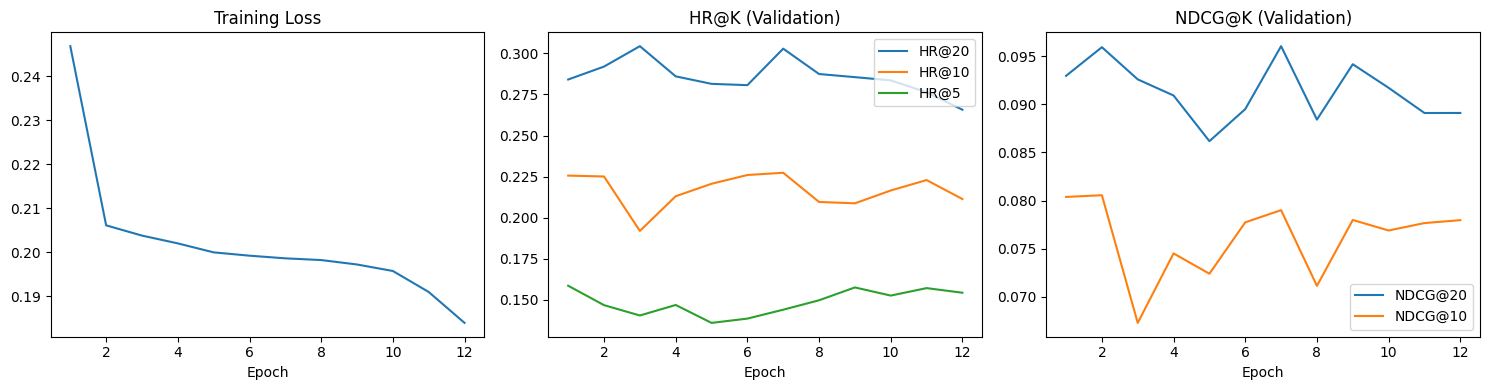

Đã lưu training_curve.png


In [ ]:
# ============================================================
# CELL 13: VẼ TRAINING CURVE (tùy chọn)
# ============================================================
import matplotlib.pyplot as plt

df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_hist['epoch'], df_hist['loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(df_hist['epoch'], df_hist['HR@20'], label='HR@20')
axes[1].plot(df_hist['epoch'], df_hist['HR@10'], label='HR@10')
axes[1].plot(df_hist['epoch'], df_hist['HR@5'],  label='HR@5')
axes[1].set_title('HR@K (Validation)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(df_hist['epoch'], df_hist['NDCG@20'], label='NDCG@20')
axes[2].plot(df_hist['epoch'], df_hist['NDCG@10'], label='NDCG@10')
axes[2].set_title('NDCG@K (Validation)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('mbgcn_training_curve.png', dpi=150)
plt.show()
print('Đã lưu training_curve.png')

In [ ]:
# ============================================================
# CELL 14: LƯU KẾT QUẢ RA FILE
# ============================================================
results_summary = {
    'model': 'MBGCN',
    'dataset': 'rees46-bpatmp-temporal',
    'behaviors': BEHAVIORS,
    'embed_dim': EMBED_DIM,
    'n_layers': N_LAYERS,
    'best_epoch': best_epoch,
    'best_val_ndcg20': best_ndcg,
    'test_results': test_results,
    'behavior_attention': {
        bhv: float(a)
        for bhv, a in zip(BEHAVIORS, F.softmax(model.behavior_attn, dim=0).detach().cpu().numpy())
    }
}

import json
with open('mbgcn_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Đã lưu kết quả vào mbgcn_results.json')
print(json.dumps(results_summary, indent=2))

Đã lưu kết quả vào mbgcn_results.json
{
  "model": "MBGCN",
  "dataset": "rees46-bpatmp-temporal",
  "behaviors": [
    "view",
    "cart",
    "purchase"
  ],
  "embed_dim": 64,
  "n_layers": 3,
  "best_epoch": 7,
  "best_val_ndcg20": 0.0960406662176148,
  "test_results": {
    "HR@1": 0.024770564242012235,
    "HR@5": 0.07847552685248131,
    "HR@10": 0.15576138681169271,
    "HR@20": 0.2207681849082257,
    "HR@50": 0.30727396329027873,
    "NDCG@1": 0.024770564242012235,
    "NDCG@5": 0.03519488406132712,
    "NDCG@10": 0.054667412991591814,
    "NDCG@20": 0.06901685953302338,
    "NDCG@50": 0.08615573185143383
  },
  "behavior_attention": {
    "view": 0.11820779740810394,
    "cart": 0.11904008686542511,
    "purchase": 0.762752115726471
  }
}
